<a href="https://colab.research.google.com/github/msiam71/RainfallSarimaModel/blob/main/rainfallFinal2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# --- Install dependencies (run only once) ---
!pip install pandas numpy matplotlib statsmodels pmdarima

# --- Import libraries ---
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 16.1 MB/s eta 0:00:00


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# --- Load and prepare data ---
df = pd.read_csv('/content/drive/MyDrive/Bangladesh_Monthly_Rainfall_GAUL.csv')
df['Date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df.set_index('Date', inplace=True)
rainfall = df.loc['2010-01-01':'2024-12-01', 'rainfall_mm']

# --- Quick data check ---
print(rainfall.describe())
print("Missing values:", rainfall.isna().sum())


count    180.000000
mean     198.304023
std      190.021987
min        1.571680
25%       16.810118
50%      152.012290
75%      344.531195
max      738.771763
Name: rainfall_mm, dtype: float64
Missing values: 0


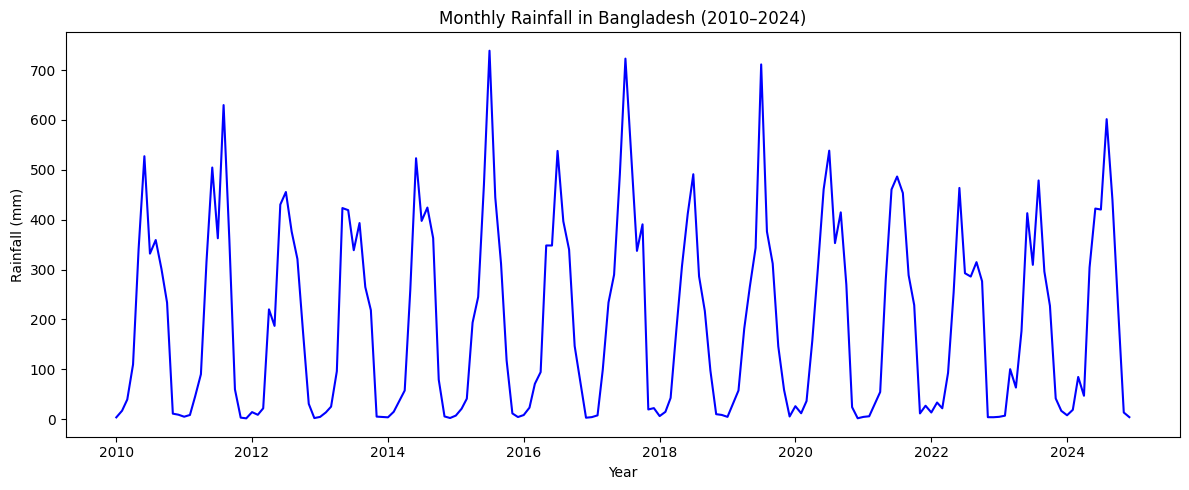

In [5]:
import matplotlib.pyplot as plt

# --- Line plot of monthly rainfall ---
plt.figure(figsize=(12,5))
plt.plot(rainfall, color='blue')
plt.title("Monthly Rainfall in Bangladesh (2010–2024)")
plt.xlabel("Year"); plt.ylabel("Rainfall (mm)")
plt.tight_layout(); plt.show()


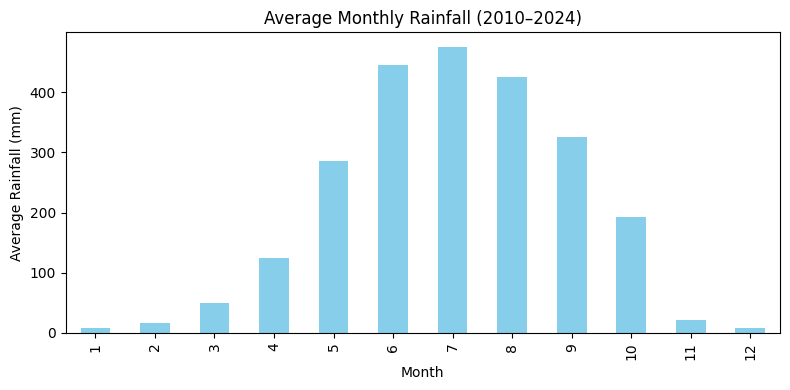

In [6]:
# --- Monthly average rainfall (seasonality) ---
monthly_avg = rainfall.groupby(rainfall.index.month).mean()
monthly_avg.plot(kind='bar', color='skyblue', figsize=(8,4))
plt.title("Average Monthly Rainfall (2010–2024)")
plt.xlabel("Month"); plt.ylabel("Average Rainfall (mm)")
plt.tight_layout(); plt.show()


In [31]:
# --- Step 3: Stationarity Checks (ADF & KPSS) ---

from statsmodels.tsa.stattools import adfuller, kpss

# ADF Test
adf_result = adfuller(rainfall.dropna())
print("ADF Statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])

# KPSS Test
kpss_result = kpss(rainfall.dropna(), regression='c', nlags='auto')
print("\nKPSS Statistic:", kpss_result[0])
print("KPSS p-value:", kpss_result[1])


ADF Statistic: -2.6137600086339092
ADF p-value: 0.09018657123345825

KPSS Statistic: 0.019466579467248363
KPSS p-value: 0.1


/tmp/ipython-input-665039891.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(rainfall.dropna(), regression='c', nlags='auto')


In [32]:
# --- Step 4: Seasonal Differencing & Re-test ---

# Apply seasonal differencing (lag=12 for monthly data)
rain_diff = rainfall.diff(12).dropna()

# Stationarity tests after differencing
from statsmodels.tsa.stattools import adfuller, kpss

print("ADF p-value (after seasonal differencing):", adfuller(rain_diff)[1])
print("KPSS p-value (after seasonal differencing):", kpss(rain_diff, regression='c', nlags='auto')[1])



ADF p-value (after seasonal differencing): 2.0408939672676067e-08
KPSS p-value (after seasonal differencing): 0.1


/tmp/ipython-input-229398191.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  print("KPSS p-value (after seasonal differencing):", kpss(rain_diff, regression='c', nlags='auto')[1])


<Figure size 1000x400 with 0 Axes>

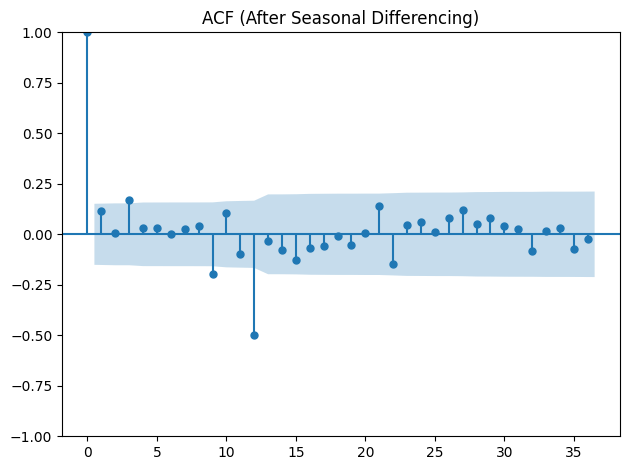

<Figure size 1000x400 with 0 Axes>

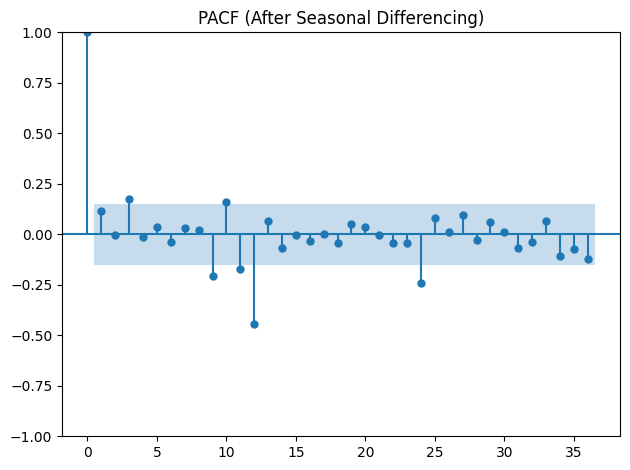

In [33]:
# --- Step 5: ACF & PACF (After Seasonal Differencing) ---

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plot_acf(rain_diff, lags=36)
plt.title("ACF (After Seasonal Differencing)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(rain_diff, lags=36)
plt.title("PACF (After Seasonal Differencing)")
plt.tight_layout()
plt.show()



In [10]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Fit your chosen SARIMA model ---
model = SARIMAX(rainfall,
                order=(1,0,1),           # p,d,q
                seasonal_order=(1,1,1,12))  # P,D,Q,s
results = model.fit(disp=False)

# --- Model summary ---
print(results.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                        rainfall_mm   No. Observations:                  180
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -962.093
Date:                            Sat, 18 Oct 2025   AIC                           1934.186
Time:                                    14:15:04   BIC                           1949.805
Sample:                                01-01-2010   HQIC                          1940.525
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7726      0.523      1.477      0.140      -0.253       1.798
ma.L1         -0.7111      0.564   

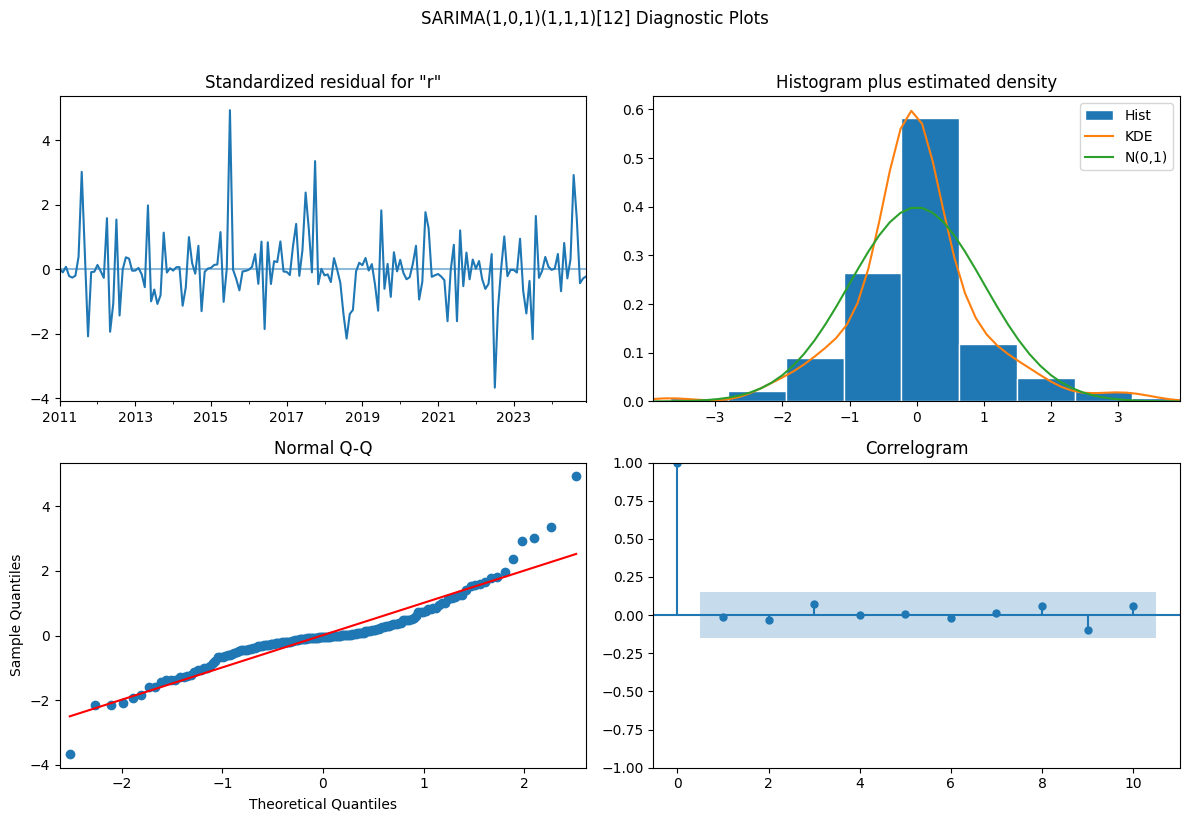

In [18]:
# --- Residual diagnostics plots ---
results.plot_diagnostics(figsize=(12,8))
plt.suptitle("SARIMA(1,0,1)(1,1,1)[12] Diagnostic Plots", y=1.02)
plt.tight_layout()
plt.show()


Forecasted Rainfall (first 5 months):
2025-01-01     13.497156
2025-02-01     20.116796
2025-03-01     71.633176
2025-04-01     78.359022
2025-05-01    251.603305
Freq: MS, Name: predicted_mean, dtype: float64


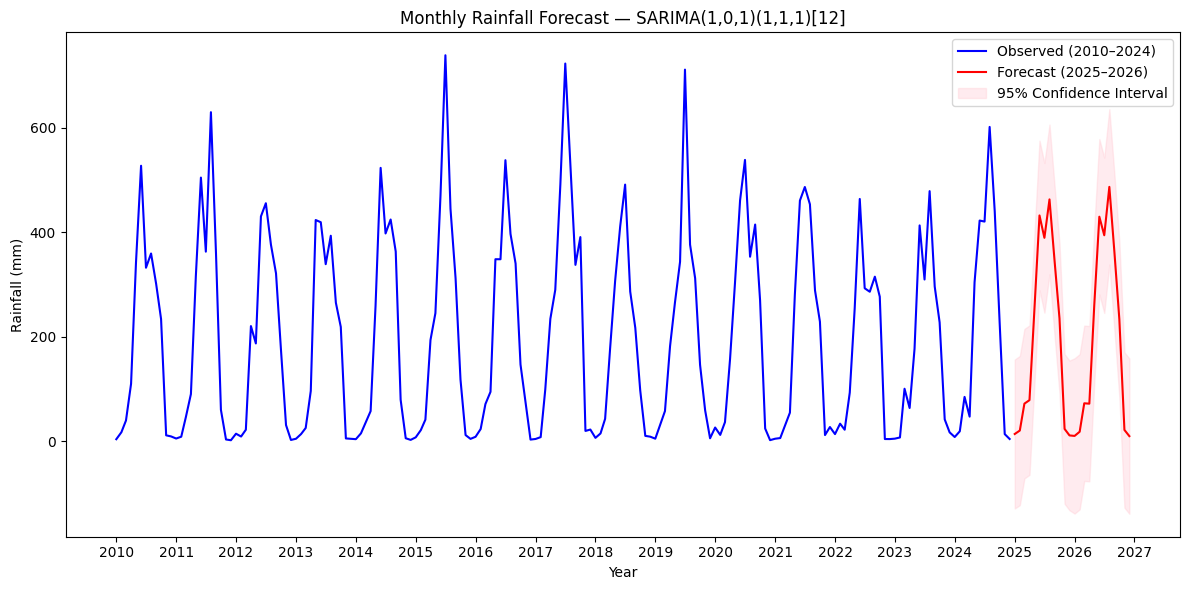

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- Forecast next 24 months ---
forecast = results.get_forecast(steps=24)

# Predicted mean and confidence intervals
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# --- Preview first few forecasted values ---
print("Forecasted Rainfall (first 5 months):")
print(pred_mean.head())

# --- Plot observed + forecast with 95% confidence interval ---
plt.figure(figsize=(12,6))
plt.plot(rainfall, label="Observed (2010–2024)", color="blue")
plt.plot(pred_mean, label="Forecast (2025–2026)", color="red")
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color="pink", alpha=0.3,
                 label="95% Confidence Interval")

# Format the x-axis (years)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=0)

plt.title("Monthly Rainfall Forecast — SARIMA(1,0,1)(1,1,1)[12]")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.legend()
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


SARIMA RMSE: 77.19   MAE: 50.31


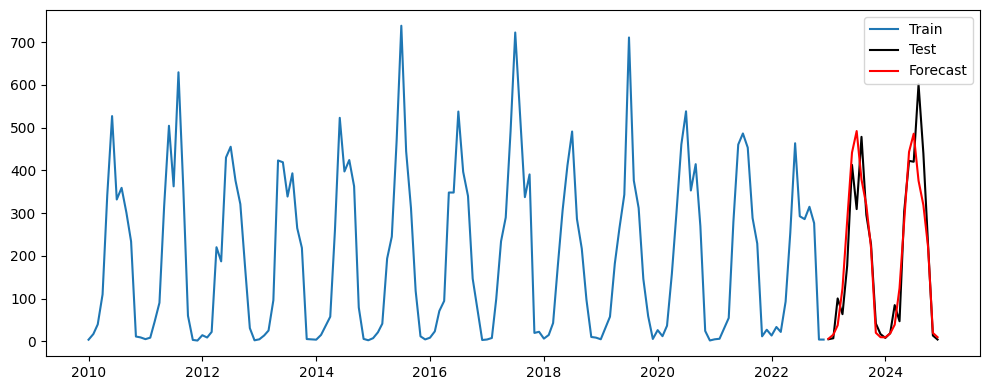

In [48]:
# --- Step 6: Train/Test forecast & metrics ---

from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Split data (last 24 months as test)
TEST_H = 24
train = rainfall.iloc[:-TEST_H]
test  = rainfall.iloc[-TEST_H:]

# Fit SARIMA on training data
model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,1,1,12),
                enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)

# Forecast test period
fc = res.get_forecast(steps=len(test))
pred = fc.predicted_mean
pred.index = test.index

# Calculate metrics
rmse = sqrt(mean_squared_error(test, pred))
mae  = mean_absolute_error(test, pred)
print(f"SARIMA RMSE: {rmse:.2f}   MAE: {mae:.2f}")

# Plot train, test, and forecast
plt.figure(figsize=(10,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test", color="black")
plt.plot(pred, label="Forecast", color="red")
plt.legend(); plt.tight_layout(); plt.show()
